# Time Series Forecasting with Temporal Fusion Transformers (TFT)

In [1]:
! pip install -q darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
from darts.models import TFTModel
import warnings
warnings.filterwarnings('ignore')

In [109]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity.csv',
                index_col='ds',parse_dates=True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8400 entries, 2016-10-22 00:00:00 to 2018-12-23 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   8400 non-null   object 
 1   y           8400 non-null   float64
 2   Exogenous1  8400 non-null   float64
 3   Exogenous2  8400 non-null   float64
dtypes: float64(3), object(1)
memory usage: 328.1+ KB


## EDA

Look at electricity pricing plots for each country.

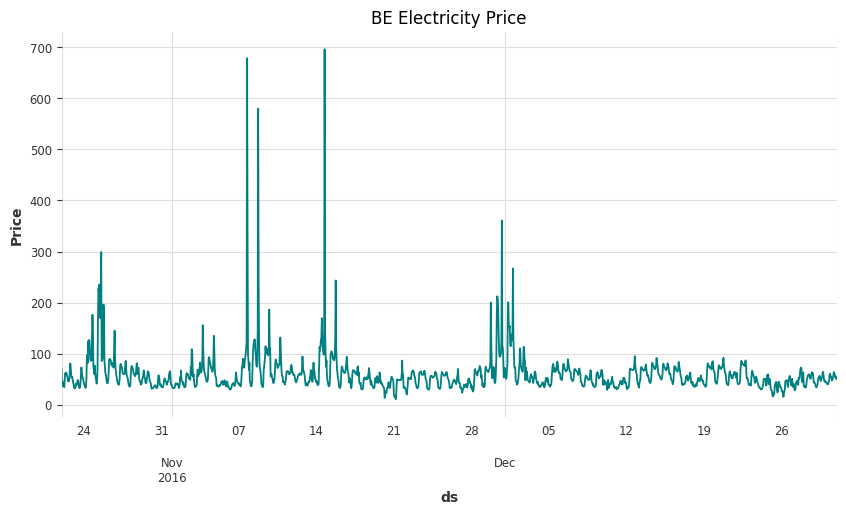

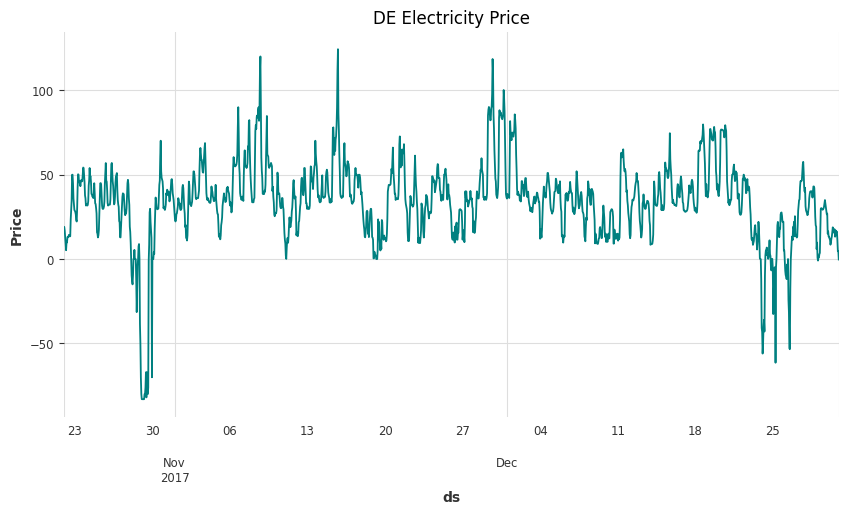

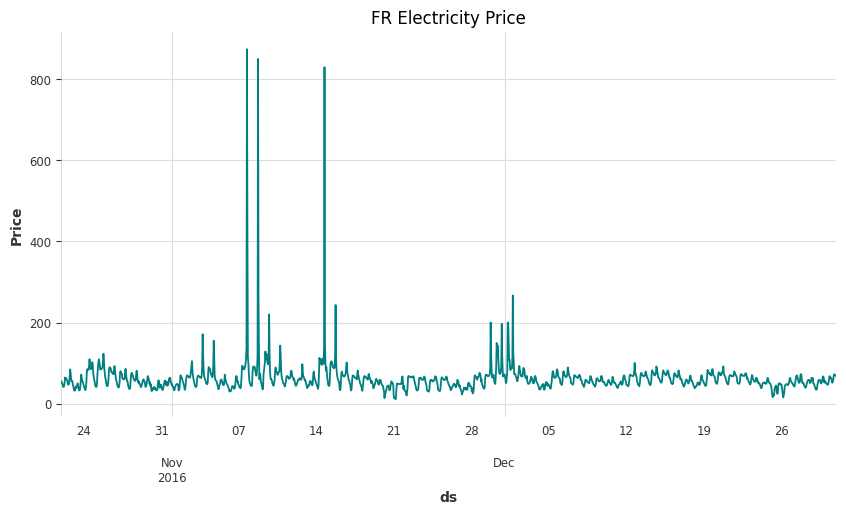

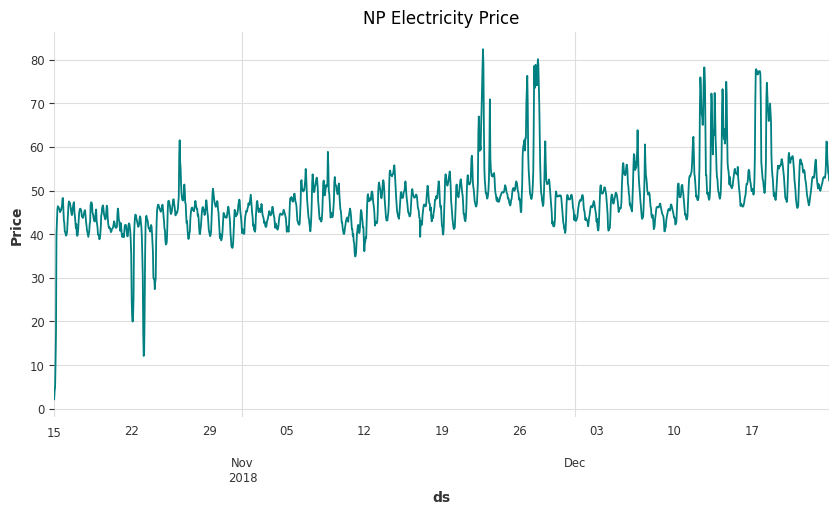

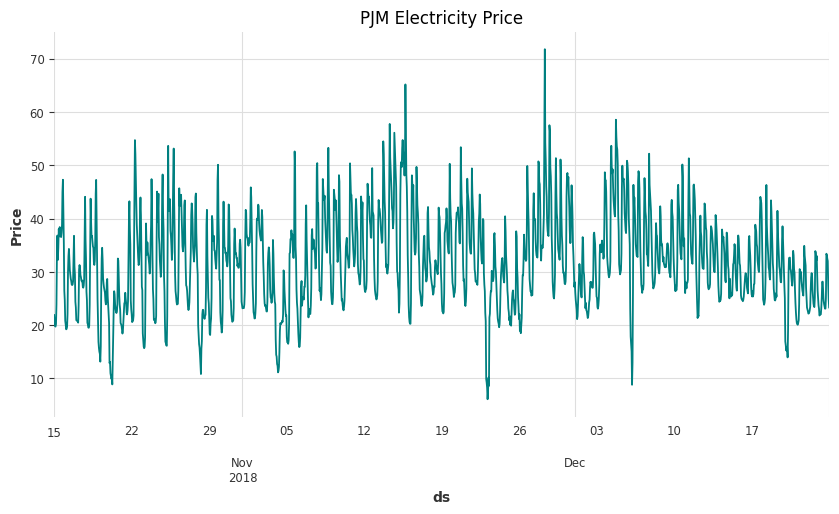

In [111]:
for country in df.unique_id.unique():
  plt.figure(figsize=(10,5))
  df[df['unique_id']==country].y.plot(title=f'{country} Electricity Price', color='teal')
  plt.ylabel('Price')
  plt.show()


Subset df for only 'DE'

In [112]:
df = df[df['unique_id']=='DE']
df = df.asfreq('H')
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2017-10-22 00:00:00,DE,19.10,587.25,16972.75
2017-10-22 01:00:00,DE,19.03,623.00,16254.50
2017-10-22 02:00:00,DE,16.90,650.00,15940.25
2017-10-22 03:00:00,DE,12.98,687.25,15959.50
2017-10-22 04:00:00,DE,9.24,717.25,16071.50


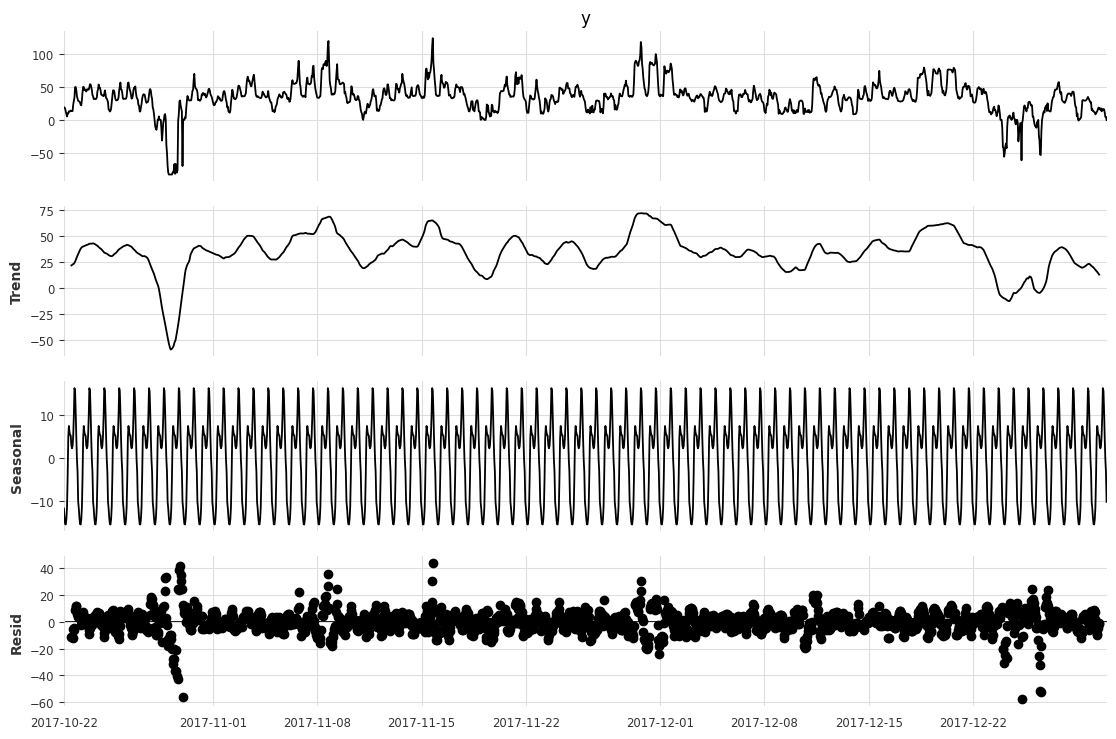

In [113]:
# Seasonal Decomposition

# Seasonal decomposition of 'Electricity Pricing'  (24 hour period, model='additive')
result = seasonal_decompose(df['y'], model='additive', period=24)
fig = result.plot()
fig.set_figheight(8)
fig.set_figwidth(12)
plt.show()

## ACF and PACF

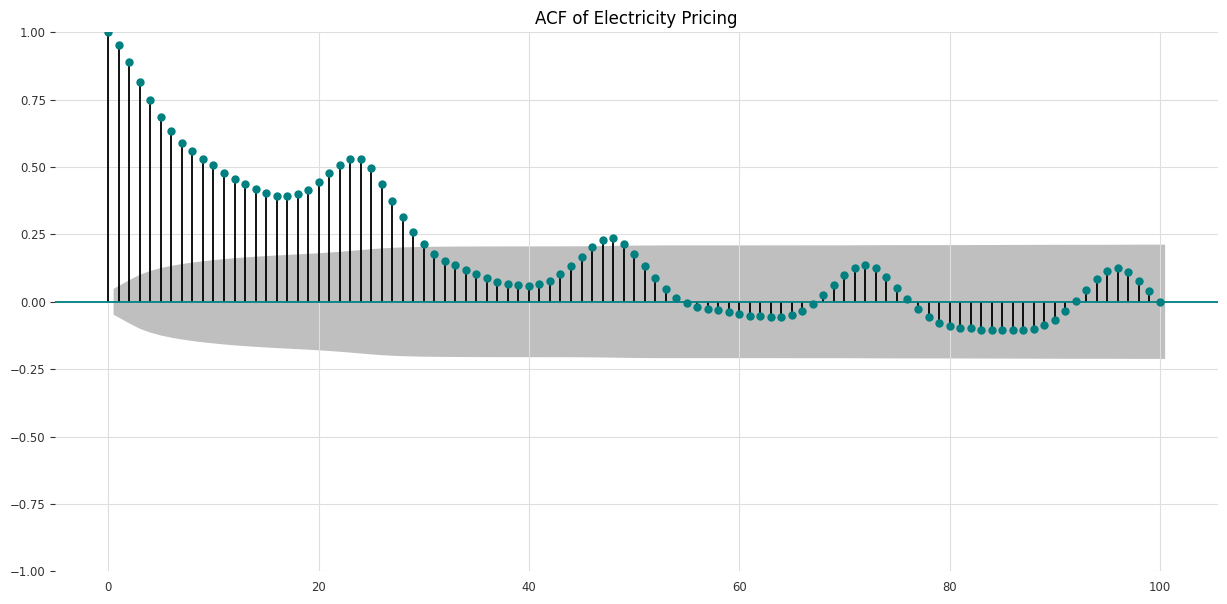

In [114]:
# Plot the ACF for the electricity pricing data
fig, ax = plt.subplots(figsize=(15,7))
plot_acf(df['y'], lags=100, ax=ax, color='teal')
plt.title('ACF of Electricity Pricing')
plt.show()

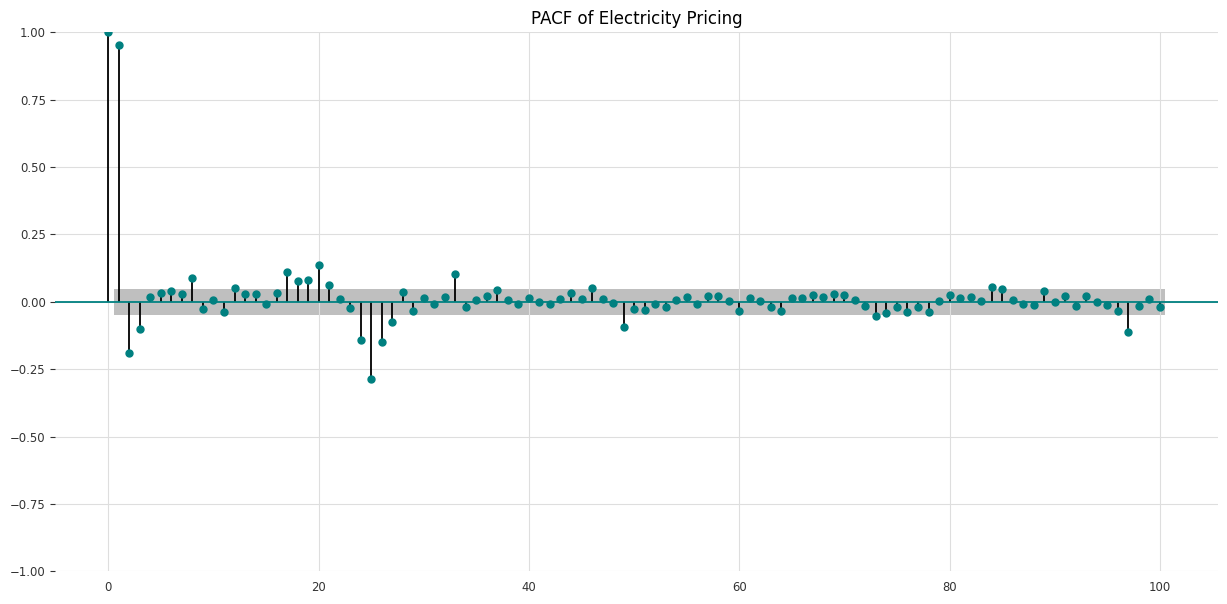

In [115]:
# Plot the PACF for the electricity pricing data
fig, ax = plt.subplots(figsize=(15,7))
plot_pacf(df['y'], lags=100, ax=ax, color='teal')
plt.title('PACF of Electricity Pricing')
plt.show()

## Stationarity

In [116]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [117]:
adf_test(df['y'])

ADF Statistic: -5.638892492656354
p-value: 1.0475477310497856e-06
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


## Time Series, Time, Static Variables

In [118]:
# Prepare the times-series object

series = TimeSeries.from_dataframe(df,
                                   value_cols = 'y'
                                   # static_covariates=,
                                   )
series

<TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
array([[[19.1 ]],

       [[19.03]],

       [[16.9 ]],

       ...,

       [[ 4.62]],

       [[ 4.71]],

       [[-0.27]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2017-10-22 ... 2017-12-30T23:00:00
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [119]:
# Time as an Encoder - the idea is to convert 'Year' to a small value for further processing

def encode_year(idx):
  return (idx.year-2000)/50  # 2000 and 50 are arbitrarily-chosen numbers

In [120]:
# An example

idx = '2017-10-22 02:00:00'
encode_year(pd.to_datetime(idx))

0.34

In [121]:
# Set up the 'add_encoders' dictionary

add_encoders = {
    'cyclic': {'future': ['hour','day','dayofweek','week','month']},
    'datetime_attribute': {'future': ['hour','day','dayofweek','week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom' : {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
    }


## Past Covariates

In [122]:
# Isolate the past covariates

X_past = df.iloc[:,2:]
X_past.head()

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50


In [123]:
X_past.tail()

,Exogenous1,Exogenous2
ds,,
2017-12-30 19:00:00,1519.50,19326.00
2017-12-30 20:00:00,1526.75,18135.25
2017-12-30 21:00:00,1514.75,17631.50
2017-12-30 22:00:00,1484.75,17553.75
2017-12-30 23:00:00,1440.75,16754.50


In [124]:
past_covariates = TimeSeries.from_dataframe(X_past)
past_covariates

<TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
array([[[  587.25],
        [16972.75]],

       [[  623.  ],
        [16254.5 ]],

       [[  650.  ],
        [15940.25]],

       ...,

       [[ 1514.75],
        [17631.5 ]],

       [[ 1484.75],
        [17553.75]],

       [[ 1440.75],
        [16754.5 ]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2017-10-22 ... 2017-12-30T23:00:00
  * component  (component) object 16B 'Exogenous1' 'Exogenous2'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

## Future Covariates

In [125]:
# Read in the future dataset

df_future = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity-future.csv',
                index_col='ds',parse_dates=True)
df_future.head()

,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [126]:
df_future.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2016-12-31 00:00:00 to 2018-12-24 23:00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   120 non-null    object 
 1   Exogenous1  120 non-null    float64
 2   Exogenous2  120 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.8+ KB


In [127]:
df_future = df_future[df_future['unique_id']=='DE']
df_future = df_future.asfreq('H')
X_future = df_future.iloc[:,1:]
X_future.head(50)

,Exogenous1,Exogenous2
ds,,
2017-12-31 00:00:00,1392.25,14744.50
2017-12-31 01:00:00,1289.00,13906.00
2017-12-31 02:00:00,1206.25,13579.00
2017-12-31 03:00:00,1120.50,13302.75
2017-12-31 04:00:00,1053.25,13232.50
2017-12-31 05:00:00,1039.75,12631.75
2017-12-31 06:00:00,1062.00,10718.25
2017-12-31 07:00:00,1101.25,10753.75
2017-12-31 08:00:00,1163.50,12495.75


In [128]:
X = pd.concat([X_past, X_future], axis=0)
X.head()

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50


In [129]:
X.tail()

,Exogenous1,Exogenous2
ds,,
2017-12-31 19:00:00,1300.00,16601.00
2017-12-31 20:00:00,1261.00,15977.75
2017-12-31 21:00:00,1243.25,15715.00
2017-12-31 22:00:00,1250.50,15876.00
2017-12-31 23:00:00,1270.75,15130.00


In [130]:
future_covariates = TimeSeries.from_dataframe(X)
future_covariates

<TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
array([[[  587.25],
        [16972.75]],

       [[  623.  ],
        [16254.5 ]],

       [[  650.  ],
        [15940.25]],

       ...,

       [[ 1243.25],
        [15715.  ]],

       [[ 1250.5 ],
        [15876.  ]],

       [[ 1270.75],
        [15130.  ]]])
Coordinates:
  * ds         (ds) datetime64[ns] 14kB 2017-10-22 ... 2017-12-31T23:00:00
  * component  (component) object 16B 'Exogenous1' 'Exogenous2'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

## Scaling

In [131]:
# Two scalers: one for the series, one for the covariates

scaler1 = Scaler()
scaler2 = Scaler()

y_transformed = scaler1.fit_transform(series)
past_covariates_transformed = scaler2.fit_transform(past_covariates)
future_covariates_transformed = scaler2.transform(future_covariates)

## TFT Model Parameters

* `input_chunk_length`: 96 hours
* `output_chunk_length` or `forecast_horizon`: 24 hours
* `hidden_size`: 16
* `LSTM_layers`: 2
* `num_attention_heads`: 4
* `dropout_rate`: 0.1
* `batch_size`: 64
* `n_epochs`: 10
* `use_static_covariates`=`True`




In [132]:
# Set forecast horizon

forecast_horizon = 24

In [133]:
# Build and fit the TFT model

tft = TFTModel(input_chunk_length=96,
               output_chunk_length=forecast_horizon,
               add_encoders=add_encoders,
               hidden_size=16,
               lstm_layers=2,
               num_attention_heads=4,
               dropout=0.1,
               batch_size=64,
               n_epochs=10,
               use_static_covariates=True,
               pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
               random_state=42,
               save_checkpoints=True,
               )

tft.fit(y_transformed,
        past_covariates=past_covariates_transformed,
        future_covariates=future_covariates_transformed,
        verbose=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7da697a34b80>], 'future': [<function encode_year at 0x7da697a34b80>]}, 'transformer': Scaler, 'tz': 'CET'}, batch_size=64, n_epochs=10, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, random_state=42, save_checkpoints=True)

## Cross Validation

In [136]:
cv = tft.historical_forecasts(
    series=y_transformed,
    past_covariates=past_covariates_transformed,
    forecast_horizon=forecast_horizon,
    start=df.shape[0] - 10*forecast_horizon,
    stride=forecast_horizon,
    retrain=True,
    last_points_only=False
    )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [137]:
cv

[<TimeSeries (ds: 24, component: 1, sample: 1)> Size: 192B
 array([[[0.84088171]],
 
        [[0.6690311 ]],
 
        [[0.52721149]],
 
        [[0.54755179]],
 
        [[0.60887411]],
 
        [[0.72459604]],
 
        [[0.50053492]],
 
        [[0.62814828]],
 
        [[0.53569223]],
 
        [[0.61696333]],
 
 ...
 
        [[0.66637087]],
 
        [[0.56648911]],
 
        [[0.70415358]],
 
        [[0.73988415]],
 
        [[0.5388043 ]],
 
        [[0.75071893]],
 
        [[0.54721887]],
 
        [[0.82690247]],
 
        [[0.82165297]],
 
        [[0.57132934]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 192B 2017-12-21 ... 2017-12-21T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  None
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 24, component: 1, sample: 1)> Size: 192B
 array([[[0.79096231]],
 
        [[0.61236073]],
 
        [[0.45727107]],
 
  

In [140]:
rsme_cv = []

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

  # Determine date range for actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.y[start:end]

  # Calculate RMSE
  error_cv = root_mean_squared_error(actuals, predictions)
  rsme_cv.append(error_cv)

print(f"The cv RMSE is: {np.mean(rsme_cv)}")
print(f"The values of cv RMSE are: {rsme_cv}")

The cv RMSE is: 31.806655171293876
The values of cv RMSE are: [23.879226929655452, 23.343880968193904, 35.24556838637724, 49.94947389064745, 40.37741180475451, 51.84231631047424, 20.639571029169453, 25.247356317028473, 26.413491707781784, 21.12825436885629]
